This notebook was created by Donyl Alcantara

# Network Topology of Reddit

### Overview

Lorem Ipsum is simply dummy text of the printing and typesetting industry. Lorem Ipsum has been the industry's standard dummy text ever since the 1500s, when an unknown printer took a galley of type and scrambled it to make a type specimen book. It has survived not only five centuries, but also the leap into electronic typesetting, remaining essentially unchanged. It was popularised in the 1960s with the release of Letraset sheets containing Lorem Ipsum passages, and more recently with desktop publishing software like Aldus PageMaker including versions of Lorem Ipsum.



## Section 1: Environment Configuration

#### 1.1 Environment Setup

In [213]:
import pandas as pd
import re
import zstandard as zstd
import io
import orjson
from collections import defaultdict
import json
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
import csv
import polars as pl
import os
import gdown
import numpy as np
import seaborn as sns
from statsmodels.distributions.empirical_distribution import ECDF
from pathlib import Path

#### 1.2 Import `user_subreddit_interactions` from `analytics`

In [2]:
df_all = pl.scan_parquet('analytics/user_subreddit_interactions.parquet').collect()
df_all = df_all.collect(

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Important_Trash_4555""","""povertyfinance""",0,16,16
"""Shatter_starx""","""pcmasterrace""",0,22,22
"""geeriveting""","""reddeadredemption""",0,1,1
"""Japparbyn""","""interestingasfuck""",0,1,1
"""BlackAbsol44""","""pcmasterrace""",1,0,1
…,…,…,…,…
"""spoonyF0rky01""","""news""",0,6,6
"""outsidewrld1""","""dating_advice""",1,0,1
"""SweetSoberCaroline""","""askreddit""",0,1,1


## Section 2: Data Pre-Processing/Exploratory Data Analysis

According to [Jakobsen (2022)](https://blog.bruun.dev/exploring-reddit-community-relations-with-graphs-and-neo4j/), due to the existence of significant noise, including the possibility of repeated interactions, specifically because of 'bot users,' we initially do the following: 

- Normalize subreddit names (done in 00)
- Filter self-referential interactions 
- Remove interactions made by top 2% users
- Remove single-interaction subreddit pairs
- Merge interactions between subreddit pairs


#### 2.1 User Activity Aggregation

In [45]:
# total interaction per author 

df_author_interaction = df_all.group_by('author').agg(
    pl.col("interaction_count").sum().alias('interaction_per_user')).sort(
    'interaction_per_user', descending=True) # convert into eager df

# create rank col
df_author_interaction = df_author_interaction.with_columns(pl.arange(
    1, df_author_interaction.height + 1).alias("rank")) # height = number of rows, width = number of cols

df_author_interaction.head(20)

author,interaction_per_user,rank
str,i64,i64
"""donut-bot""",163298,1
"""TipOfTheirTongue""",162697,2
"""VisualMod""",100202,3
"""MinecraftModBot""",89755,4
"""MrPuma86""",65225,5
…,…,…
"""Sky-876""",20904,16
"""bvandepol""",20343,17
"""AskWomen-ModTeam""",20105,18


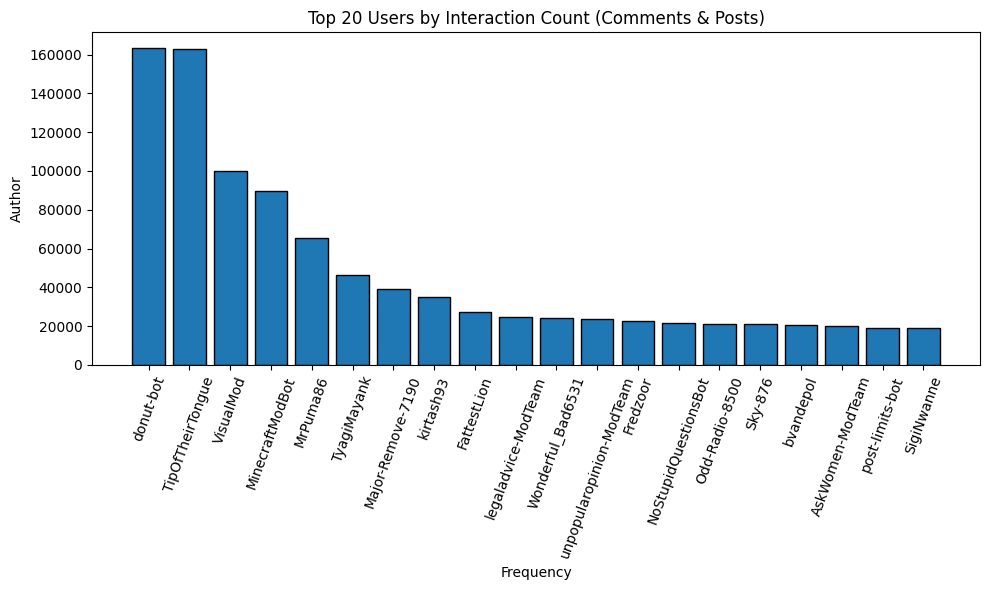

In [56]:
# top 20 

# bar graph
plt.figure(figsize=(10, 6))
plt.bar(df_author_interaction['author'].head(20),
        df_author_interaction['interaction_per_user'].head(20),
        edgecolor='black')
plt.title("Top 20 Users by Interaction Count (Comments & Posts)")
plt.xlabel("Frequency")
plt.ylabel("Author")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

#### 2.2 Rank-Frequency Profiling

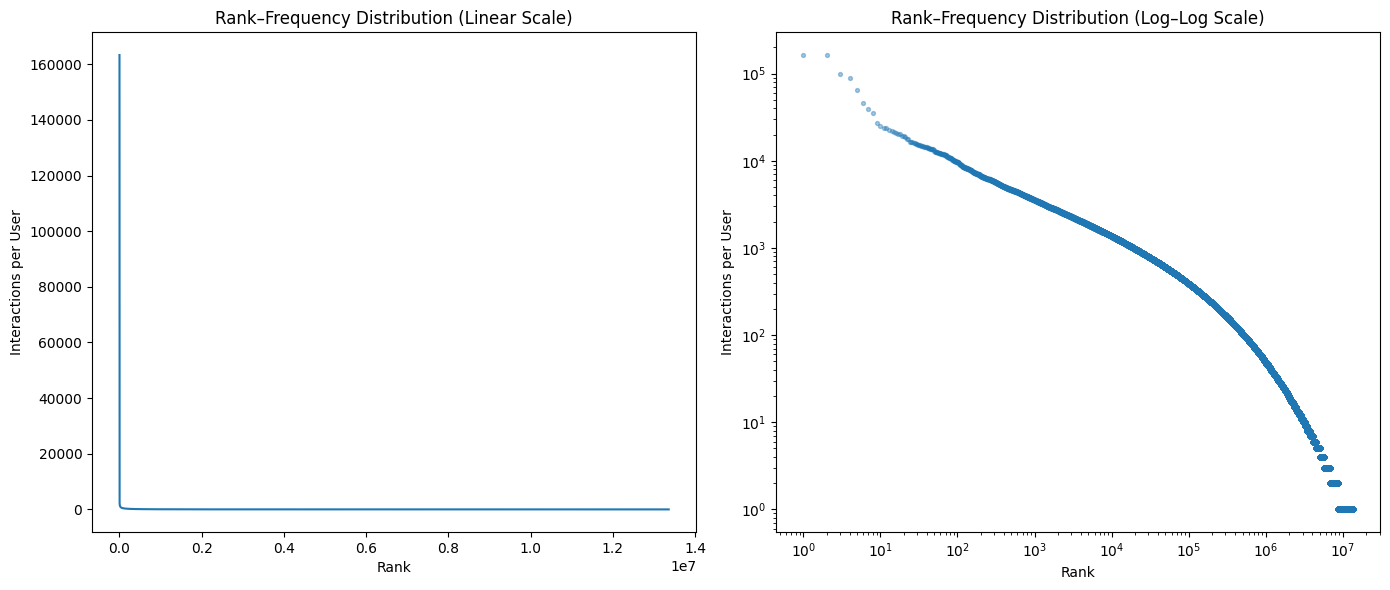

In [128]:
# visualize the long-tail dist with and without scaling
# convert polars series to numpy
x = df_author_interaction['rank'].to_numpy()
y = df_author_interaction['interaction_per_user'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Linear scale
axes[0].plot(x, y)
axes[0].set_title("Rank–Frequency Distribution (Linear Scale)")
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Interactions per User")

# Log–Log scale
axes[1].scatter(x, y, alpha=0.4, s=8, color='#1f77b4')
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Rank–Frequency Distribution (Log–Log Scale)")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("Interactions per User")

plt.tight_layout()
plt.show()

#### 2.3 Outlier/Noise Detection 

#### Log Interquartile Range (IQR)

In [139]:
data = df_author_interaction["interaction_per_user"].to_numpy()
log_data = np.log1p(data)

Q1 = np.percentile(log_data, 25)
Q3 = np.percentile(log_data, 75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = data[log_data > upper_bound]

print(f"Outlier threshold: {np.expm1(upper_bound):.0f}")

Outlier threshold: 111


#### Contribution Share

The distribution of user activity exhibits a pronounced long-tail. We observe a high concentration of activity among a small subset of users: the top 2% of contributors account for approximately 47% of all interactions. This extreme inequality suggests that a small number of highly active users disproportionately shape the interaction network. To mitigate this bias and reduce potential noise from automated or hyperactive accounts, we remove users whose interaction counts fall within the top 2% of the distribution.

In [177]:
# sort descending
df_cs = df_author_interaction.sort("interaction_per_user", descending=True)
total_interactions = df_cs["interaction_per_user"].sum()

# iterate over top 1 to 20%
for pct in range(1, 21):
    n_top = int(df_cs.height * (pct/100))
    top_users = df_cs.head(n_top)
    share = top_users["interaction_per_user"].sum() / total_interactions
    print(f"Top {pct}% users: {n_top}, Contribution share: {share:.2f}")

Top 1% users: 133614, Contribution share: 0.35
Top 2% users: 267228, Contribution share: 0.47
Top 3% users: 400842, Contribution share: 0.55
Top 4% users: 534456, Contribution share: 0.60
Top 5% users: 668070, Contribution share: 0.65
Top 6% users: 801684, Contribution share: 0.68
Top 7% users: 935298, Contribution share: 0.71
Top 8% users: 1068912, Contribution share: 0.74
Top 9% users: 1202526, Contribution share: 0.76
Top 10% users: 1336140, Contribution share: 0.77
Top 11% users: 1469754, Contribution share: 0.79
Top 12% users: 1603368, Contribution share: 0.81
Top 13% users: 1736983, Contribution share: 0.82
Top 14% users: 1870597, Contribution share: 0.83
Top 15% users: 2004211, Contribution share: 0.84
Top 16% users: 2137825, Contribution share: 0.85
Top 17% users: 2271439, Contribution share: 0.86
Top 18% users: 2405053, Contribution share: 0.86
Top 19% users: 2538667, Contribution share: 0.87
Top 20% users: 2672281, Contribution share: 0.88


#### Lorenz Curve and Gini Coefficient

The Gini coefficient of user interactions is 0.83, indicating extreme inequality. The top 2% of users generate 47% of all interactions, confirming that a small subset of highly active users dominates the network. To reduce the influence of these extreme contributors, we remove users within the top 2% of the distribution.

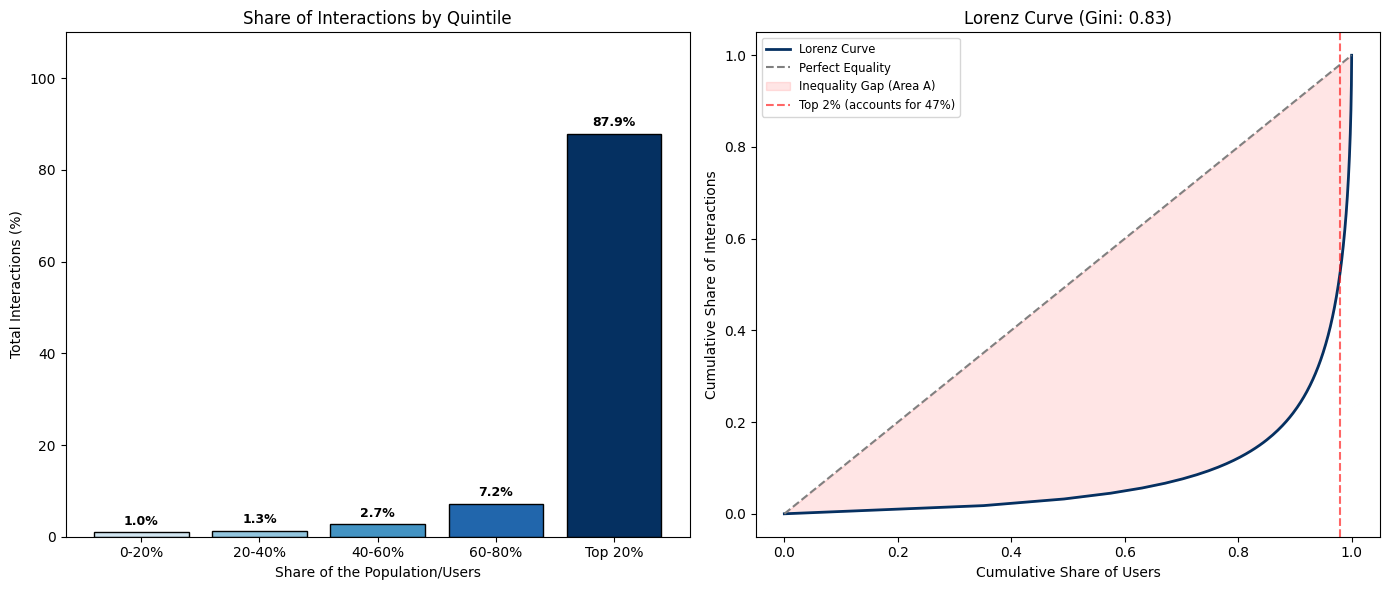

In [205]:
y_sorted = np.sort(df_author_interaction["interaction_per_user"].to_numpy())
total_val = y_sorted.sum()
n_users = len(y_sorted)

# lorenz data
cum_users = np.arange(1, n_users + 1) / n_users
cum_activity = np.cumsum(y_sorted) / total_val

# quintile data
groups = np.array_split(y_sorted, 5)
shares = [(g.sum() / total_val) * 100 for g in groups]
quintile_labels = ['0-20%', '20-40%', '40-60%', '60-80%', 'Top 20%']
colors = ['#d1e5f0', '#92c5de', '#4393c3', '#2166ac', '#053061']

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Quintile Bar Chart
bars = ax1.bar(quintile_labels, shares, color=colors, edgecolor='black')
ax1.set_title('Share of Interactions by Quintile')
ax1.set_ylabel('Total Interactions (%)')
ax1.set_xlabel('Share of the Population/Users')
ax1.set_ylim(0, 110)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# Lorenz Curve
ax2.plot(cum_users, cum_activity, label='Lorenz Curve', color='#053061', linewidth=2)
ax2.plot([0,1], [0,1], linestyle='--', color='grey', label='Perfect Equality')
ax2.fill_between(cum_users, cum_activity, cum_users, color='red', alpha=0.1, label='Inequality Gap (Area A)')

# threshold 
ax2.axvline(cum_users[int(len(lor_data) * 0.98)], linestyle='--', color='r', alpha=0.6, label=f'Top 2% (accounts for {(1-cum_activity[int(len(lor_data) * 0.98)])*100:.0f}%)')
# ax2.axhline(cum_activity[int(len(lor_data) * 0.98)], linestyle=':', color='r', alpha=0.5)
ax2.set_title(f'Lorenz Curve (Gini: {gini:.2f})')
ax2.set_xlabel('Cumulative Share of Users')
ax2.set_ylabel('Cumulative Share of Interactions')
ax2.legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

#### 98th Percentile vs. Power-law xmin

Top 2% threshold: 185.00
Power-law xmin: 622.00


/var/folders/_g/nz39y46d1l93yjn3vj6_jd100000gn/T/ipykernel_1577/3840720732.py:36: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


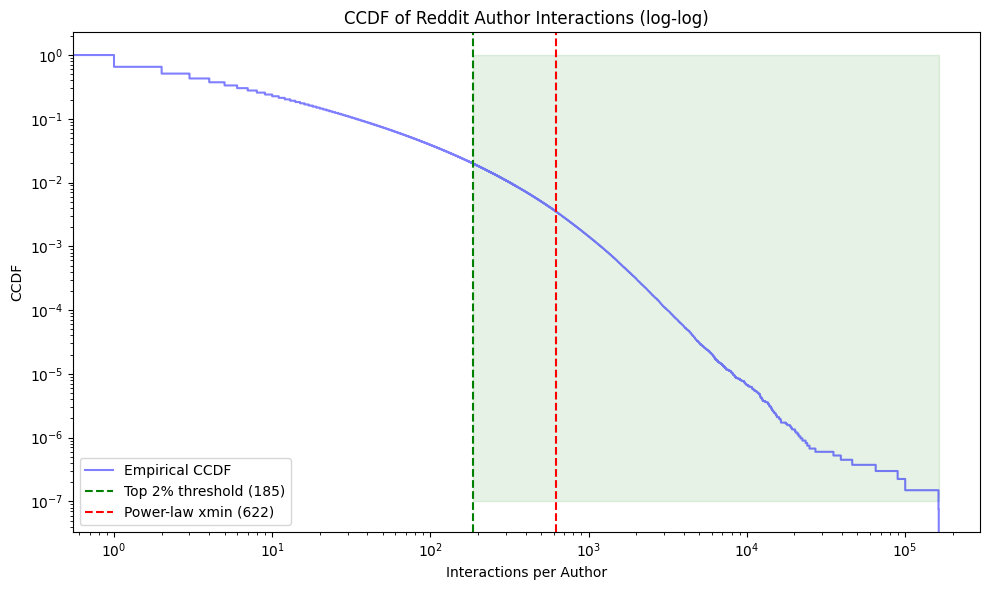

In [206]:
# Data
data = df_author_interaction["interaction_per_user"].to_numpy()

# Compute thresholds
threshold_2pct = np.percentile(data, 98)

print(f"Top 2% threshold: {threshold_2pct:.2f}")
print(f"Power-law xmin: {xmin:.2f}")

# Compute ECDF and CCDF
ecdf = ECDF(data)
ccdf = 1 - ecdf.y  # CCDF = 1 - CDF

# plot CCDF
plt.figure(figsize=(10,6))
plt.step(ecdf.x, ccdf, where='post', color='blue', alpha=0.5, label='Empirical CCDF')
plt.xscale('log')  # log-log scale
plt.yscale('log')

# threshold lines
plt.axvline(threshold_2pct, color='green', linestyle='--',  
            label=f'Top 2% threshold ({threshold_2pct:.0f})')
plt.axvline(xmin, color='red', linestyle='--',
            label=f'Power-law xmin ({xmin:.0f})')

# shade the top 2%
plt.fill_betweenx(y=[1e-7, 1], x1=threshold_2pct, x2=ecdf.x.max(),
                  color='green', alpha=0.1)

# labels
plt.xlabel("Interactions per Author")
plt.ylabel("CCDF")
plt.title("CCDF of Reddit Author Interactions (log-log)")
# plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [207]:
# Compare Power Law vs. Log-normal
R, p = fit.distribution_compare('power_law', 'lognormal')

print(f"Loglikelihood ratio (R): {R:.2f}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    if R > 0:
        print("Conclusion: Reject H0. Power Law is a significantly better fit.")
    else:
        print("Conclusion: Reject H0. Log-normal is a significantly better fit.")
else:
    print("Conclusion: Fail to reject H0. Neither distribution is significantly better.")

Loglikelihood ratio (R): -198.21
p-value: 0.0000
Conclusion: Reject H0. Log-normal is a significantly better fit.


Log-normal parameters: mu=3.15, sigma=1.45


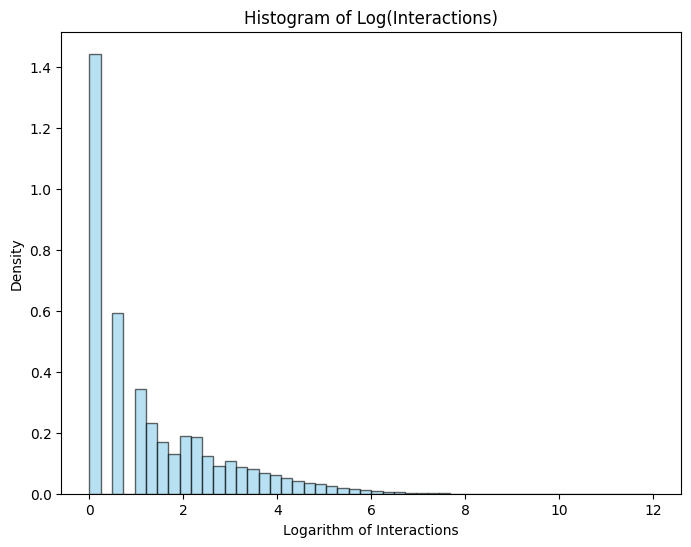

In [208]:
# Extract parameters from the fit
mu = fit.lognormal.mu
sigma = fit.lognormal.sigma

print(f"Log-normal parameters: mu={mu:.2f}, sigma={sigma:.2f}")

# Verification: Plot the histogram of the LOG of the data
log_data = np.log(data[data > 0])
plt.figure(figsize=(8, 6))
plt.hist(log_data, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.title('Histogram of Log(Interactions)')
plt.xlabel('Logarithm of Interactions')
plt.ylabel('Density')
plt.show()

Calculating best minimal value for power law fit


Fitting xmin: 100%|█████████████████████████| 4101/4101 [06:38<00:00, 10.29it/s]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


Text(0.5, 1.0, 'CDF Comparison: Empirical vs. Theoretical')

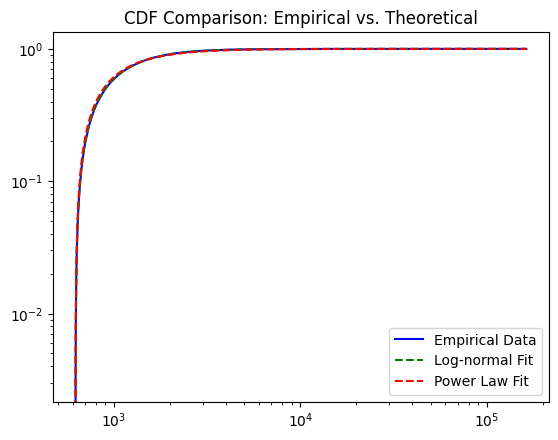

In [210]:
# Plotting the CDF comparison
fit = powerlaw.Fit(y_sorted)
fig = fit.plot_cdf(color='b', label='Empirical Data')
fit.lognormal.plot_cdf(color='g', linestyle='--', ax=fig, label='Log-normal Fit')
fit.power_law.plot_cdf(color='r', linestyle='--', ax=fig, label='Power Law Fit')
plt.legend()
plt.title("CDF Comparison: Empirical vs. Theoretical")

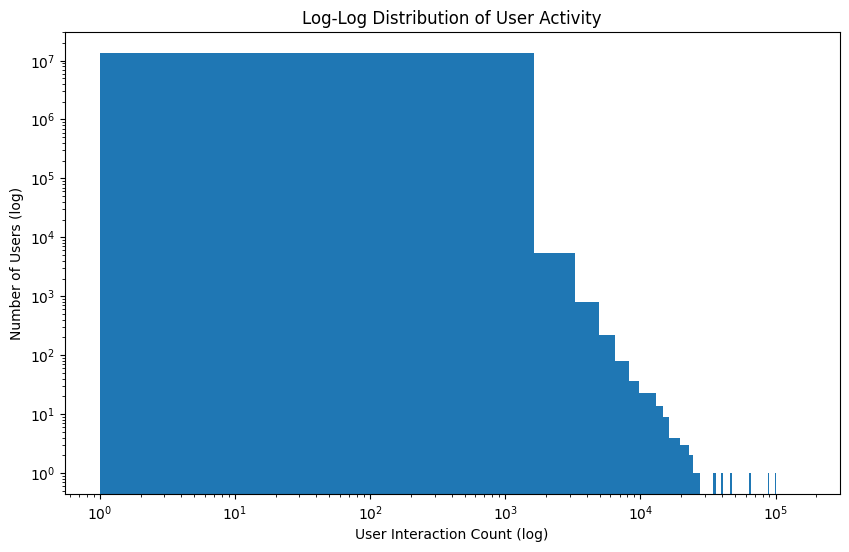

In [111]:
# distribution or histogram 

plt.figure(figsize=(10,6))
plt.hist(y, bins=100)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("User Interaction Count (log)")
plt.ylabel("Number of Users (log)")
plt.title("Log-Log Distribution of User Activity")
plt.show()

In [71]:
# get the top 2% df to detect bots and extreme users

threshold_filter = df_author_interaction.select(pl.col('interaction_per_user').quantile(0.98)).item()

df_top_users = df_author_interaction.filter(
    pl.col('interaction_per_user') > threshold_filter).select('author')

display(df_top_users)
print(f'98th Percentile: {threshold_filter}')

author
str
"""donut-bot"""
"""TipOfTheirTongue"""
"""VisualMod"""
"""MinecraftModBot"""
"""MrPuma86"""
…
"""jonny3jack"""
"""PiratesTale"""
"""MeLlamoDave"""


98th Percentile: 185.0


In [86]:
# remove top 2%

final_auti = df_author_interaction.join(
    df_top_users,
    on='author',
    how='anti').sort('rank', descending=False)

final_auti

author,interaction_per_user,rank
str,i64,i64
"""Chrysania83""",185,266712
"""kevin82485""",185,266713
"""KishCore""",185,266714
"""mh_1983""",185,266715
"""Jumbalaa""",185,266716
…,…,…
"""prototype_A1""",1,13361404
"""ChiefSloanKEa""",1,13361405
"""Substantial-Egg-6679""",1,13361406


In [77]:
# sanity check 
top_users_count = df_top_users.height
total_users = df_author_interaction.height
pct = top_users_count / total_users
print(f'{pct:.4f}')

0.0200


In [107]:
# clean df_all (remove top users)

clean_df_all = df_all.join(
    final_auti.select("author"),
    on="author",
    how="inner"
)

display(clean_df_all)

print("\nSummary:")
print("Before Removing Top 2%:", df_all.height, "rows")
print("After Removing Top 2%:", clean_df_all.height, "rows")
print("No. of Rows Removed:", df_all.height - clean_df_all.height, "rows")
print(f"Percentage of Rows Removed: {((df_all.height - clean_df_all.height)/df_all.height)*100:.2f}%")

# 2% of users contributed 14.43% of the total interactions, which is exactly what the long-tail dist shows, hence the need
# to remove them

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Important_Trash_4555""","""povertyfinance""",0,16,16
"""geeriveting""","""reddeadredemption""",0,1,1
"""Japparbyn""","""interestingasfuck""",0,1,1
"""BlackAbsol44""","""pcmasterrace""",1,0,1
"""One-Personality3513""","""houseofthedragon""",2,1,3
…,…,…,…,…
"""spoonyF0rky01""","""news""",0,6,6
"""outsidewrld1""","""dating_advice""",1,0,1
"""SweetSoberCaroline""","""askreddit""",0,1,1



Summary:
Before Removing Top 2%: 46724134 rows
After Removing Top 2%: 39981748 rows
No. of Rows Removed: 6742386 rows
Percentage of Rows Removed: 14.43%


In [216]:
# save to analytics/parquet
# clean_df_all.write_parquet("analytics/clean_df_all.parquet")